## Table of Contents

- [Introduction](#Introduction)
  - [Remarks](#Remarks)
- [Self-organising Map Code Block and Observations](#Self-organising-Map-Code-Block-and-Observations)
- [An Alternative Approach](#An-Alternative-Approach)
- [How to Productionise](#How-to-Productionise)
  - [Online Inference](#Online-Inference)
  - [Batch Inference](#Batch-Inference)
  - [Event-driven Inference](#Event-driven-Inference)

## Introduction

This notebook will try to evaluate the code black that lives in `train()` method below. We will benchmark the code, and provide alternative ways to speed up the calculations. We will also provide guidance around how we can put the training code into production. Where relevant, we will also provide code snippets.

### Remarks
- Project root includes bare-bones setup initiated using [`uv`](https://docs.astral.sh/uv/getting-started/installation/). If you have `uv` and `make` installed, you can simply run `make install` to build the virtual environment. If you do not have `uv`, you can install the dependencies using `pip`.
- Feel free to run the code blocks as they are.
- Benchmark being provided here is very naive.
  - For the sake of simplicity, we are altering the grid size in uniform step sizes.
  - Ideally, a benchmark would run multiple times on a given set of inputs, and grab the stats of the worst run.

## Self-organising Map Code Block and Observations

Below is the code snippet that provides a way to calculate the weights of a self-organising mapping (SOM) given number of maximum iterations, width and height of the 2D output layer.

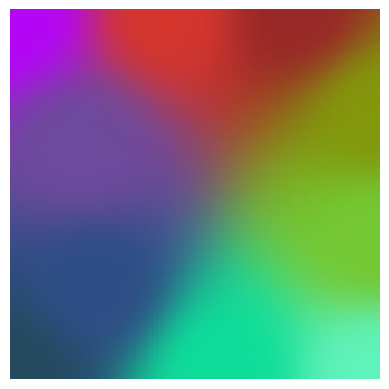

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def train(input_data, n_max_iterations, width, height):
    σ0 = max(width, height) / 2
    α0 = 0.1
    weights = np.random.random((width, height, 3))
    λ = n_max_iterations / np.log(σ0)
    for t in range(n_max_iterations):
        σt = σ0 * np.exp(-t/λ)
        αt = α0 * np.exp(-t/λ)
        for vt in input_data:
            bmu = np.argmin(np.sum((weights - vt) ** 2, axis=2))
            bmu_x, bmu_y = np.unravel_index(bmu, (width, height))
            for x in range(width):
                for y in range(height):
                    di = np.sqrt(((x - bmu_x) ** 2) + ((y - bmu_y) ** 2))
                    θt = np.exp(-(di ** 2) / (2*(σt ** 2)))
                    weights[x, y] += αt * θt * (vt - weights[x, y])
    return weights

input_data = np.random.random((10, 3))
image_data = train(input_data, 1000, 100, 100)

plt.imshow(image_data)
plt.axis("off")
plt.show()

Here are some initial observations:

- As is, for large grids with lots of iterations, the function take a very long time to calculate the map.
- There is no restriction, or validation around the function parameters. For example, you cannot really have negative iterations, or if you provide an output layer of size 2x2, you will get a divide-by-zero error since `log(1) = 0`.
- `weights` is set per training, and the dimension is fixed to `3` which is easy to miss if you decide to provide a different `input_data` dimension.
- The way code is presented is only for scripting. A function like that is really not suitable for production consumption.
- Usage of non-alphanumeric variable names is not really desirable. It makes maintenance rather difficult.

Below is a plot showing the execution time in seconds for changing grid sizes with fixed iterations for each step.

<img src="plots/baseline.png" width="40%">

## An Alternative Approach

We aim to have different approach for the algorithm that
- reduces execution time for large grids,
- provides necessary controls, and validations,
- improves maintainability, and ultimately,
- allows easy migration to production.

The calculations needed for SOM has an advantage that we can use; vectorisation. There are also calculations that can be done once. One shortfall of the given code block is mising validations. This can be solved using Pydantic. This allows us to check the incoming data, and provides a safe way of accessing training configuration. Here is an example training configuration.

In [27]:
from typing import Annotated

from numpy import ndarray
from pydantic import BaseModel, Field


class Config(BaseModel):
    n_max_iterations: Annotated[int, Field(gt=0)]
    width: Annotated[int, Field(gt=2)]
    height: Annotated[int, Field(gt=2)]
    learning_rate: float = 0.1

The main nested `for` loop calculating the distances, influence of each node, and the final update of the weights can be vectorised in its own function definition.

In [28]:
def update_weights(
    w: ndarray,
    d: ndarray,
    grid_x: ndarray,
    grid_y: ndarray,
    bmu_x: ndarray,
    bmu_y: ndarray,
    radius_decay: float,
    learning_rate_decay: float,
) -> None:
    grid_distance = np.sqrt(((grid_x - bmu_x) ** 2) + ((grid_y - bmu_y) ** 2))
    influence = np.exp(-(grid_distance**2) / (2 * (radius_decay**2)))
    # np.newaxis allows propagation of the learning_rate_decay * influence to (d - w).
    # (d - w) is of the shape (m, m 1) whereas learning_rate_decay * influence is of the shape (m, n)
    w += learning_rate_decay * influence[..., np.newaxis] * (d - w)

This allows us now to simplify the main train function as below. `radius_decay` and `learning_rate_decay` are pre-calculated. Since iterations are managed by `n_max_iterations`, this makes sense to pre-calculate them rather than re-calculate these values every iteration.

In [29]:
def train(input_data: ndarray, weights: ndarray, config: Config) -> ndarray:
    if input_data.shape[-1] != weights.shape[-1]:
        raise ValueError(
            f"input_data feature dim ({input_data.shape[-1]}) must match "
            f"weights feature dim ({weights.shape[-1]})"
        )

    neighbour_radius = max(config.width, config.height) / 2
    radius_decay_const = config.n_max_iterations / np.log(neighbour_radius)

    radius_decay = [neighbour_radius * np.exp(-t / radius_decay_const) for t in range(config.n_max_iterations)]
    learning_rate_decay = [
        config.learning_rate * np.exp(-t / radius_decay_const) for t in range(config.n_max_iterations)
    ]

    grid_x, grid_y = np.indices((config.width, config.height))

    for i in range(config.n_max_iterations):
        for d in input_data:
            bmu = np.argmin(np.sum((weights - d) ** 2, axis=2))
            bmu_x, bmu_y = np.unravel_index(bmu, (config.width, config.height))

            update_weights(
                w=weights,
                d=d,
                grid_x=grid_x,
                grid_y=grid_y,
                bmu_x=bmu_x,
                bmu_y=bmu_y,
                radius_decay=radius_decay[i],
                learning_rate_decay=learning_rate_decay[i],
            )

    return weights

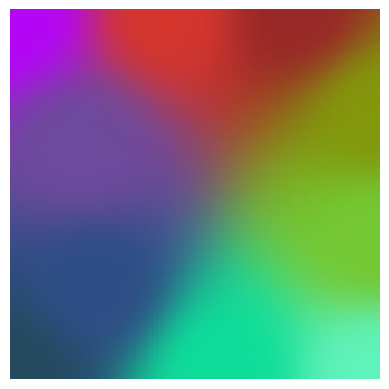

In [33]:
training_config = Config(n_max_iterations=1000, width=100, height=100)

input_data = np.random.random((10, 3))
weights = np.random.random((training_config.width, training_config.height, 3))
image_data = train(input_data, weights, training_config)

plt.imshow(image_data)
plt.axis("off")
plt.show()

The refactorisation drastically decreases the execution time for growing grid size. We can do the exact same benchmarking we did for the code block before refactorisation. Calculations per each grid size has a significance decrease in execution time.

<img src="plots/refactored.png" width="40%">

Below is combined plots in log-scale for easier comparison.

<img src="plots/comparison.png" width="40%">

## How to Productionise

There are few things that we need to consider before we can put this into production. We will not focus on the different use cases as steps involved in getting this into production does not change with the use case. Below is a rough outline of what we need. Please mind this is not an exhaustive list since what we actually need will depend on the larger system design. The list below can be thought of as minimal things that would enable versioned weights, and a way for retraining.

1. We need to be able to (re-)train, and produce/update the weights for a given training dataset. Versioning, and tracking what's in production will be important here.
2. We will need a way to store, load, and serve the weights whatever use case we are thinking. Based on the use case, we will need tools to make use of the weights.
3. We will need to store the experimentation inference results as well as online inference results for future adjustments.

Majority of the necessities can be solved by moving SOME training into its own package. The package itself can be built, and contains the trained weights as loadable artifact. We would need to have functions that enable training, and inference. Each development, or improvement to the algorithm would be published with a version ideally through a CI/CD pipeline. Having a versioned package would allow us to control what we have in production, and would help with evaluation of the new versions.

Having development, and storing weights in a package solves a few problems:

- We do not need 3rd party artifact storage like MLFlow which comes with additional costs, and management.
- Specific version of the SOME can be installed in application deployments by simply installing it as a dependency.
- We can keep training, inference, and evaluation all together which allows us to mitigate the 2-system problem that a lot of ML systems is suffering from.
- If we ever want to move to an automated re-training, packaged versioning is advantageous. Because, a well-organised CI/CD pipeline can re-train, publish new versions, and use specific versions for evaluation all in one place. Of course, this increases complexity, but this is a trade-off we would need to consider.
- A packaged approach allows utilisation of the model in all inference deployment models; online, batch, or event-driven.


In terms of infrastructure needed for different inference mode, there are a few different ways this application can be put into production. Each of the options below depends on the requirements, and overall system design that this application is part of.

- Online inference
- Batch inference
- Event-driven inference

All the options described below assume we have observability, and monitoring of the system. Hence, we omit mentioning of setup of cluster provisioning, roles setup, CI/CD pipeline, New Relic, Sumologic, PagerDuty, Grafana, etc.

### Online Inference

If there are other systems wanting to take advantage of a SOM, or a tool that generates the results of clustering on a UI, a containerised FastAPI application deployed to a k8s cluster serving requests is an ideal way to get this into production. An HPA configuration with scaling factor based on CPU utilisation is a good start for meeting the latency requirements of an online application. This can be later on switched to a more complex scaling options like KEDA.

### Batch Inference

A batch inference solution does not have to worry about latency of the system. In this option, availability of compute will be the most important part as well as parallelisation. Utilisation of Dask, or Ray would help to cut costs down to speed up the batch processing. There are a few important aspects of batch inference that will need careful design.

- There will need to be a unique way of batching to mitigate possible data leakage between batches as well as maintain idempotence of the calculations and write events.
- Number of batches being processed will need to be adjusted based on the concurrency limits defined on the target (relational database, or a blob storage).
- If failed batches needs to be retried, there will need to be a way to reprocess them. This will introduce additional complexities like integrating a dead-letter queue.

### Event-driven Inference

This is probably the most complicated option due to the number of components that is required to achieve stability, and reliable processing of the events. This option should only be considered if your use case is producing events in high volumes. There are few components to this architecture:

- an event stream (Kafka, etc.)
- a consumer of the events + a queue (SQS) with a dead-letter queue for failed event processing
- a service (a lightweight FastAPI app running in lifecycle loop) that consumes events from the queue, and produces inference results

The downstream application would consume from the target that we write inference results to. The shape changes based on the use case.